# 3W Dataset: Anomaly Detection with a VAE on Real Data

Alternative use of the same generative machinery: a VAE trained **only on
Normal instances** (class 0, 597 real instances) learns the normal operating
envelope. Any instance whose reconstruction error is far from the training
distribution is an anomaly, that is, one of the 8 undesirable events. The VAE
is scored against three classical detectors (Mahalanobis, kNN, Isolation
Forest) with ROC-AUC and F1 at a fixed threshold.


## 1. Data Preparation

We work with the **real instances** of the 3W dataset, summarized into
56-dimensional statistical feature vectors (7 statistics x 8 variables) with
the same pipeline as the augmentation notebook.


In [1]:
import os, glob, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)


In [2]:
# ── Paths and dataset constants ──
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']


In [3]:
def detect_source(filename: str) -> str:
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):   return 'handdrawn'
    if name.startswith('SIMULATED'): return 'simulated'
    if name.startswith('WELL'):    return 'real'
    return 'unknown'

def load_all_instances(data_dir: str, class_names: list) -> dict:
    all_instances = {}
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            df = pd.read_csv(fpath)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            instance_id = os.path.splitext(fname)[0]
            if source not in class_instances:
                class_instances[source] = []
            class_instances[source].append({
                'id': instance_id, 'path': fpath, 'data': df,
                'n_vars': len([c for c in df.columns if c not in ('timestamp', 'class')]),
                'n_obs': df.shape[0],
            })
        if class_instances:
            all_instances[class_code] = class_instances
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')


Loaded 1984 instances across 9 classes.


In [4]:
# ── Feature engineering (same pipeline as stage 2) ──
# 7 statistics (mean, std, min, p25, p50, p75, max) x 8 variables = 56 features.
# NaN -> column median (or 0 if whole column is NaN), inf -> clipped.
def extract_features(data: dict, source: str, classes: list) -> tuple:
    """
    Extract statistical features per instance.
    Returns (X, y, instance_ids): X is (n_instances, n_features), y the class labels.
    """
    features = []
    labels = []
    instance_ids = []

    for cls in classes:
        if cls not in data or source not in data[cls]:
            continue
        for inst in data[cls][source]:
            df = inst['data']
            feats = []
            for var in VARIABLE_NAMES:
                if var in df.columns:
                    vals = df[var].values
                    feats.extend([
                        np.nanmean(vals),
                        np.nanstd(vals),
                        np.nanmin(vals),
                        np.nanpercentile(vals, 25),
                        np.nanpercentile(vals, 50),
                        np.nanpercentile(vals, 75),
                        np.nanmax(vals),
                    ])
                else:
                    feats.extend([np.nan] * 7)

            features.append(feats)
            labels.append(cls)
            instance_ids.append(inst['id'])

    X = np.array(features, dtype=np.float64)
    y = np.array(labels)

    # nan values are replaced with column medians (or 0 if entire column is NaN)
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    for j in range(X.shape[1]):
        if np.isnan(col_medians[j]):
            col_medians[j] = 0.0
        X[nan_mask[:, j], j] = col_medians[j]

    # replace inf values with column max/min (or 1/-1 if entire column is inf)
    for j in range(X.shape[1]):
        col = X[:, j]
        finite_vals = col[np.isfinite(col)]
        if len(finite_vals) > 0:
            col_max = np.max(finite_vals)
            col_min = np.min(finite_vals)
        else:
            col_max, col_min = 1.0, -1.0
        col[~np.isfinite(col) & (col > 0)] = col_max
        col[~np.isfinite(col) & (col < 0)] = col_min
        # clipping to avoid extreme values
        X[:, j] = np.clip(col, -1e15, 1e15)

    return X, y, instance_ids

stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]

X_real, y_real, ids_real = extract_features(data, 'real', sorted(CLASS_NAMES))
print(f'Real feature matrix: {X_real.shape} ({len(feature_names)} feature dimensions)')
counts = pd.Series(y_real).value_counts().sort_index()
pd.DataFrame({'class': counts.index, 'n_real': counts.values,
              'event': [CLASS_NAMES[c][:28] for c in counts.index]})


Real feature matrix: (1025, 56) (56 feature dimensions)


,class,n_real,event
0,0,597,Normal
1,1,5,Abrupt Increase of BSW
2,2,22,Spurious Closure of DHSV
3,3,32,Severe Slugging
4,4,344,Flow Instability
5,5,12,Rapid Productivity Loss
6,6,6,Quick Restriction in PCK
7,7,4,Scaling in PCK
8,8,3,Hydrate in Production Line


## 2. Fixed train/test split

**Identical split to the augmentation notebook** (same seed 42, same
instance-level stratified 70/30) so the two experiments are directly
comparable. Only class 0 is used for training the VAE; all 9 classes are used
for testing.


In [5]:
RARE_CLASSES = [1, 5, 6, 7, 8]

real_by_class = {c: list(data[c]['real']) for c in sorted(CLASS_NAMES) if 'real' in data.get(c, {})}
all_insts, y_all = [], []
for c in sorted(real_by_class):
    all_insts.extend(real_by_class[c])
    y_all.extend([c] * len(real_by_class[c]))

tr_idx, te_idx, _, _ = train_test_split(
    np.arange(len(all_insts)), y_all, test_size=0.3, stratify=y_all, random_state=42)

def build_dict(idx):
    d = {}
    for i in idx:
        inst, c = all_insts[i], y_all[i]
        d.setdefault(c, {'real': []})['real'].append(inst)
    return d

data_train = build_dict(tr_idx)
data_test = build_dict(te_idx)
print(f'Real instances: train {len(tr_idx)}, test {len(te_idx)} (total {len(all_insts)})')


Real instances: train 717, test 308 (total 1025)


In [6]:
X_train, y_train, ids_train = extract_features(data_train, 'real', sorted(CLASS_NAMES))
X_test, y_test, ids_test = extract_features(data_test, 'real', sorted(CLASS_NAMES))
print(f'Train features: {X_train.shape}, test features: {X_test.shape}')

def class_counts(y):
    return pd.Series(y).value_counts().sort_index()

tbl = pd.DataFrame({'train': class_counts(y_train), 'test': class_counts(y_test)})
tbl['event'] = [CLASS_NAMES[c][:28] for c in tbl.index]
tbl


Train features: (717, 56), test features: (308, 56)


,train,test,event
0,418,179,Normal
1,4,1,Abrupt Increase of BSW
2,15,7,Spurious Closure of DHSV
3,22,10,Severe Slugging
4,241,103,Flow Instability
5,8,4,Rapid Productivity Loss
6,4,2,Quick Restriction in PCK
7,3,1,Scaling in PCK
8,2,1,Hydrate in Production Line


## 3. VAE model and training on Normal (class 0)

Same encoder/decoder architecture as the CVAE, minus the class condition.
Standardization is fit on class-0 training instances only; every test instance
(including faulty ones) is transformed with the same statistics.

**Architecture:**
- **Encoder**: Input (56 features) → 64 → 64 → μ, σ (latent dim = 8)
- **Decoder**: Latent (8) → 64 → 64 → 56 reconstructed features
- **Loss**: Reconstruction (MSE) + KL Divergence


In [7]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden=64):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu_head(h), self.logvar_head(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def elbo_loss(x, x_rec, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_rec, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu ** 2 - torch.exp(logvar))
    return recon + beta * kl, recon, kl


In [8]:
X0 = X_train[y_train == 0]
mu0 = np.mean(X0, axis=0)
sd0 = np.std(X0, axis=0)
degenerate0 = sd0 < 1e-12
sd0[degenerate0] = 1.0

def zscore(X):
    return ((X - mu0) / sd0).astype(np.float32)

X0_std = zscore(X0)
print(f'Class 0 train instances: {len(X0)}, degenerate (constant) columns: {degenerate0.sum()}')
print(f'Class 0 test instances:  {int(np.sum(y_test == 0))} (used as negatives)')
print(f'Faulty test instances:   {int(np.sum(y_test != 0))} across 8 event classes')


Class 0 train instances: 418, degenerate (constant) columns: 7
Class 0 test instances:  179 (used as negatives)
Faulty test instances:   129 across 8 event classes


epoch  25 | ELBO 0.7299 | recon 0.6394 | KL 0.0905


epoch  50 | ELBO 0.5993 | recon 0.4786 | KL 0.1207


epoch  75 | ELBO 0.5440 | recon 0.3961 | KL 0.1479


epoch 100 | ELBO 0.5197 | recon 0.3641 | KL 0.1556


epoch 125 | ELBO 0.4598 | recon 0.2872 | KL 0.1726


epoch 150 | ELBO 0.4640 | recon 0.2704 | KL 0.1936


epoch 175 | ELBO 0.4370 | recon 0.2388 | KL 0.1982


epoch 200 | ELBO 0.4220 | recon 0.2156 | KL 0.2065

Final mean KL: 0.2065 nats/sample -> healthy


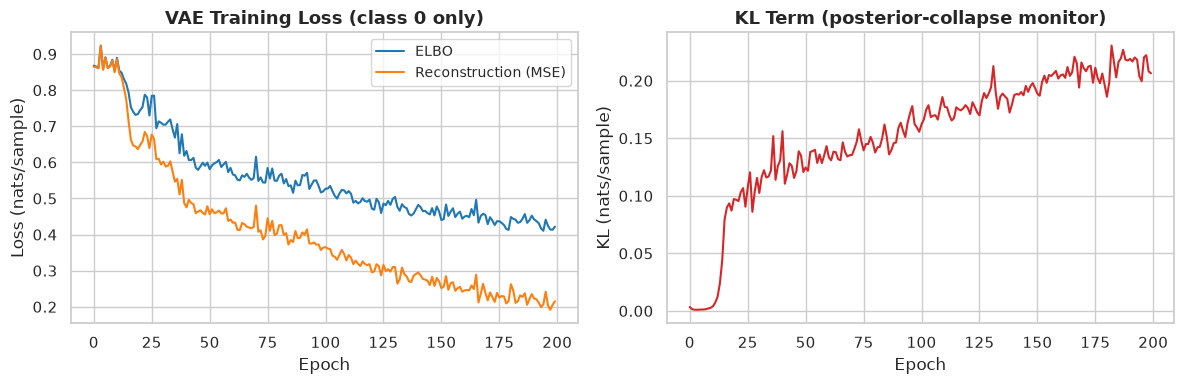

In [9]:
seed_everything(42)
model = VAE(input_dim=X_train.shape[1], latent_dim=8, hidden=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(torch.tensor(X0_std)), batch_size=64, shuffle=True)

history = {'elbo': [], 'recon': [], 'kl': []}
for epoch in range(1, 201):
    model.train()
    e_elbo = e_recon = e_kl = 0.0
    n_batches = 0
    for (xb,) in loader:
        optimizer.zero_grad()
        x_rec, mu, logvar = model(xb)
        loss, recon, kl = elbo_loss(xb, x_rec, mu, logvar)
        loss.backward()
        optimizer.step()
        e_elbo += loss.item(); e_recon += recon.item(); e_kl += kl.item()
        n_batches += 1
    history['elbo'].append(e_elbo / n_batches)
    history['recon'].append(e_recon / n_batches)
    history['kl'].append(e_kl / n_batches)
    if epoch % 25 == 0:
        print(f'epoch {epoch:3d} | ELBO {history["elbo"][-1]:.4f} | recon {history["recon"][-1]:.4f} | KL {history["kl"][-1]:.4f}')

print(f'\nFinal mean KL: {history["kl"][-1]:.4f} nats/sample',
      '-> posterior collapse warning' if history['kl'][-1] < 0.05 else '-> healthy')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['elbo'], label='ELBO', color='#1f77b4', linewidth=1.5)
axes[0].plot(history['recon'], label='Reconstruction (MSE)', color='#ff7f0e', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (nats/sample)')
axes[0].set_title('VAE Training Loss (class 0 only)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[1].plot(history['kl'], color='#d62728', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('KL (nats/sample)')
axes[1].set_title('KL Term (posterior-collapse monitor)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Anomaly scoring

Anomaly score = per-sample mean squared reconstruction error on the
standardized features. The threshold is fixed at the 95th percentile of the
**training** normal scores; no test data is used to set it.


In [10]:
@torch.no_grad()
def anomaly_scores(model, X_std, batch=256):
    model.eval()
    scores = []
    for i in range(0, len(X_std), batch):
        x = torch.tensor(X_std[i:i + batch])
        x_rec, mu, logvar = model(x)
        scores.append(((x - x_rec) ** 2).mean(dim=1).numpy())
    return np.concatenate(scores)

scores_train_norm = anomaly_scores(model, X0_std)
thr = np.percentile(scores_train_norm, 95)
scores_test = anomaly_scores(model, zscore(X_test))
print(f'Anomaly threshold (p95 of train-normal scores): {thr:.4f}')
print(f'Train-normal score range: [{scores_train_norm.min():.4f}, {scores_train_norm.max():.4f}]')


Anomaly threshold (p95 of train-normal scores): 0.5885
Train-normal score range: [0.0024, 4.4233]


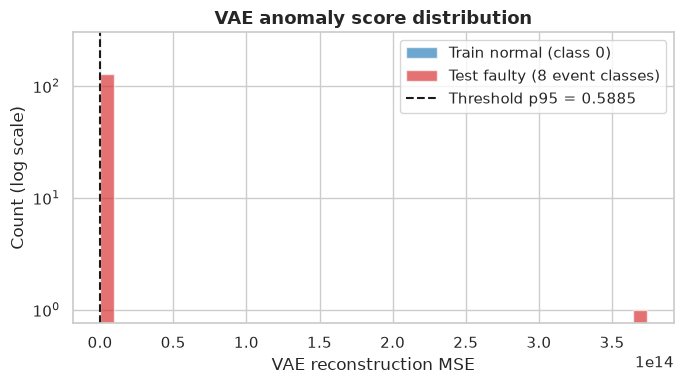

,class,event,n,mean score,mean / normal p95
0,1,Abrupt Increase of BSW,1,1.363467e+00,2.316671e+00
1,2,Spurious Closure of DHSV,7,9.493949e+02,1.613120e+03
2,3,Severe Slugging,10,1.321273e+03,2.244979e+03
3,4,Flow Instability,103,1.654105e+01,2.810496e+01
4,5,Rapid Productivity Loss,4,1.138595e+04,1.934591e+04
5,6,Quick Restriction in PCK,2,5.683562e-01,9.656960e-01
6,7,Scaling in PCK,1,3.736577e+14,6.348830e+14
7,8,Hydrate in Production Line,1,8.512333e+05,1.446334e+06


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_train_norm, bins=30, alpha=0.65, label='Train normal (class 0)', color='#1f77b4')
fault_scores = scores_test[y_test != 0]
ax.hist(fault_scores, bins=40, alpha=0.65, label='Test faulty (8 event classes)', color='#d62728')
ax.axvline(thr, color='k', ls='--', label=f'Threshold p95 = {thr:.4f}')
ax.set_yscale('log')
ax.set_xlabel('VAE reconstruction MSE'); ax.set_ylabel('Count (log scale)')
ax.set_title('VAE anomaly score distribution', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

score_rows = []
for c in sorted(CLASS_NAMES):
    if c == 0:
        continue
    mask = y_test == c
    if mask.sum() == 0:
        continue
    score_rows.append({'class': c, 'event': CLASS_NAMES[c][:26], 'n': int(mask.sum()),
                       'mean score': scores_test[mask].mean(),
                       'mean / normal p95': scores_test[mask].mean() / thr})
score_df = pd.DataFrame(score_rows)
display(score_df)


## 5. Baselines

Three classical detectors on the same standardized feature space, scored with
the same protocol (threshold = p95 of their own training-normal scores):
Mahalanobis distance, kNN (k=5) mean neighbor distance, Isolation Forest
(negative decision function).


In [12]:
# Mahalanobis distance
mu_m = np.mean(X0_std, axis=0)
cov_m = np.cov(X0_std, rowvar=False) + 1e-6 * np.eye(X0_std.shape[1])
cov_inv = np.linalg.pinv(cov_m)
def mahalanobis_scores(X):
    dx = X - mu_m
    return np.einsum('ij,jk,ik->i', dx, cov_inv, dx)

# kNN (k=5) mean neighbor distance
knn = NearestNeighbors(n_neighbors=5).fit(X0_std)
def knn_scores(X):
    dists, _ = knn.kneighbors(X)
    return dists.mean(axis=1)

# Isolation Forest (negative decision function: higher = more anomalous)
iso = IsolationForest(contamination='auto', random_state=42).fit(X0_std)
def iso_scores(X):
    return -iso.decision_function(X)

train_scores = {'VAE (recon MSE)': scores_train_norm,
                'Mahalanobis': mahalanobis_scores(X0_std),
                'kNN (k=5)': knn_scores(X0_std),
                'IsolationForest': iso_scores(X0_std)}
test_scores = {'VAE (recon MSE)': scores_test,
               'Mahalanobis': mahalanobis_scores(zscore(X_test)),
               'kNN (k=5)': knn_scores(zscore(X_test)),
               'IsolationForest': iso_scores(zscore(X_test))}
print('Methods:', list(test_scores))


Methods: ['VAE (recon MSE)', 'Mahalanobis', 'kNN (k=5)', 'IsolationForest']


## 6. Evaluation: ROC-AUC and F1@p95

Per-class ROC-AUC (positives = test instances of class c, negatives = the 179
class-0 test instances). Classes with n_test < 3 are flagged as unreliable;
their AUC is a 1-4 sample estimate. Macro-AUC is computed over the reliable
classes only. F1@p95 is measured at the fixed threshold on the full test set
(faulty vs normal), plus per-class recall at that threshold.


In [13]:
auc_rows = []
for c in sorted(CLASS_NAMES):
    if c == 0:
        continue
    n_pos = int(np.sum(y_test == c))
    if n_pos == 0:
        continue
    y_true = (y_test == c)
    for mname, scores in test_scores.items():
        auc_rows.append({'class': c, 'event': CLASS_NAMES[c][:24], 'n_test': n_pos,
                         'method': mname, 'AUC': roc_auc_score(y_true, scores),
                         'reliable': n_pos >= 3})

auc_df = pd.DataFrame(auc_rows)
auc_pivot = auc_df.pivot(index='class', columns='method', values='AUC')
auc_pivot['n_test'] = auc_df.groupby('class')['n_test'].first()
auc_pivot['reliable'] = auc_pivot['n_test'] >= 3
display(auc_pivot)

macro_auc = auc_df[auc_df['reliable']].groupby('method')['AUC'].mean().round(3)
print('Macro-AUC over classes with n_test >= 3 (classes 2, 3, 4, 5):')
display(macro_auc)


method,IsolationForest,Mahalanobis,VAE (recon MSE),kNN (k=5),n_test,reliable
class,,,,,,
1,0.671010,0.827362,0.846906,0.833876,1,False
2,0.741813,0.938301,0.965828,0.966303,7,True
3,1.000000,0.984564,0.979195,0.978859,10,True
4,0.846223,0.843618,0.730239,0.861189,103,True
5,0.921875,0.888980,0.947368,0.922697,4,True
6,0.575163,0.839869,0.704248,0.710784,2,False
7,0.677524,1.000000,1.000000,1.000000,1,False
8,0.944625,0.996743,0.996743,0.996743,1,False


Macro-AUC over classes with n_test >= 3 (classes 2, 3, 4, 5):


method
IsolationForest    0.877
Mahalanobis        0.914
VAE (recon MSE)    0.906
kNN (k=5)          0.932
Name: AUC, dtype: float64

In [14]:
f1_rows = []
recall_rows = []
for mname in test_scores:
    thr_m = np.percentile(train_scores[mname], 95)
    y_true_f = (y_test != 0)
    y_pred_f = test_scores[mname] > thr_m
    f1_rows.append({
        'method': mname,
        'F1@p95': f1_score(y_true_f, y_pred_f),
        'precision': precision_score(y_true_f, y_pred_f),
        'recall': recall_score(y_true_f, y_pred_f),
    })
    for c in sorted(CLASS_NAMES):
        if c == 0:
            continue
        mask = y_test == c
        if mask.sum() == 0:
            continue
        recall_rows.append({'method': mname, 'class': c, 'n_test': int(mask.sum()),
                            'recall@p95': np.mean(test_scores[mname][mask] > thr_m)})

print('F1 / precision / recall at the fixed p95 threshold (faulty vs normal):')
f1_df = pd.DataFrame(f1_rows)
display(f1_df)

print('Per-class recall at the fixed p95 threshold:')
recall_pivot = pd.DataFrame(recall_rows).pivot(index='class', columns='method', values='recall@p95')
recall_pivot['n_test'] = pd.DataFrame(recall_rows).groupby('class')['n_test'].first()
display(recall_pivot)


F1 / precision / recall at the fixed p95 threshold (faulty vs normal):


,method,F1@p95,precision,recall
0,VAE (recon MSE),0.666667,0.845238,0.550388
1,Mahalanobis,0.857143,0.812500,0.906977
2,kNN (k=5),0.805031,0.677249,0.992248
3,IsolationForest,0.767241,0.864078,0.689922


Per-class recall at the fixed p95 threshold:


method,IsolationForest,Mahalanobis,VAE (recon MSE),kNN (k=5),n_test
class,,,,,
1,1.000000,1.000000,1.000000,1.000000,1
2,1.000000,1.000000,1.000000,1.000000,7
3,1.000000,1.000000,1.000000,1.000000,10
4,0.621359,0.883495,0.446602,0.990291,103
5,1.000000,1.000000,1.000000,1.000000,4
6,0.500000,1.000000,0.500000,1.000000,2
7,1.000000,1.000000,1.000000,1.000000,1
8,1.000000,1.000000,1.000000,1.000000,1


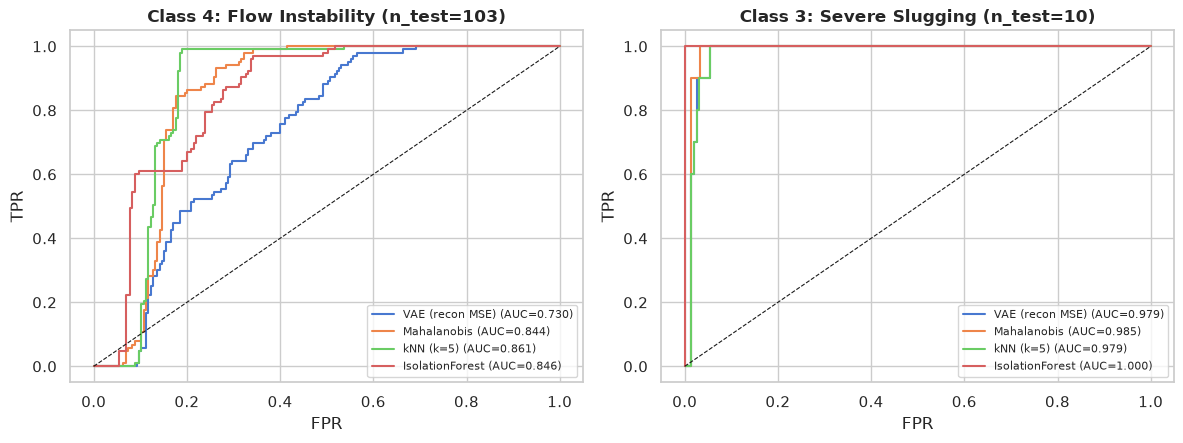

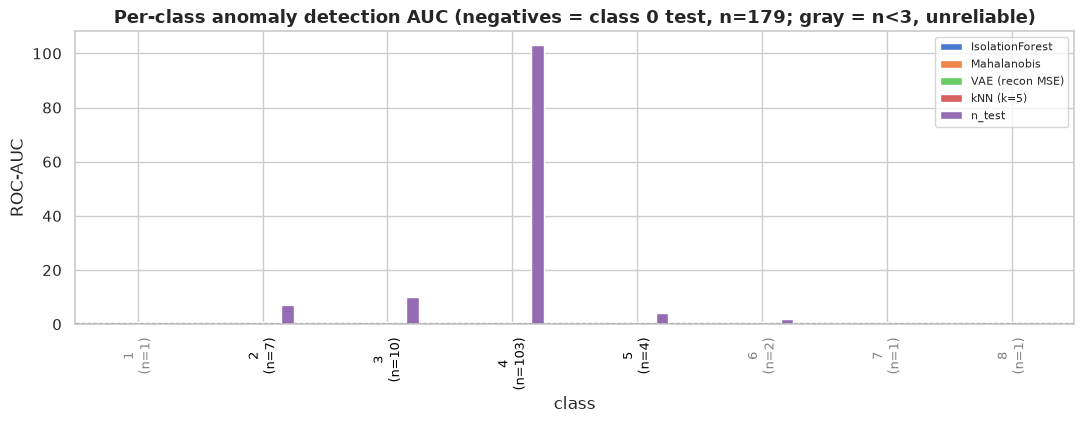

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, c in zip(axes, [4, 3]):   # class 4 (n=103) and class 3 (n=10): the reliable classes
    y_true = (y_test == c)
    for mname, scores in test_scores.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(fpr, tpr, label=f'{mname} (AUC={roc_auc_score(y_true, scores):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'Class {c}: {CLASS_NAMES[c][:30]} (n_test={int(np.sum(y_test == c))})', fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.4))
plot_df = auc_pivot.drop(columns=['reliable'])
plot_df.plot(kind='bar', ax=ax)
ax.set_ylabel('ROC-AUC')
ax.set_xticklabels([f'{int(c)}\n(n={int(n)})' for c, n in zip(plot_df.index, auc_pivot['n_test'])], fontsize=9)
ax.axhline(0.5, color='k', ls='--', lw=0.8)
ax.set_title('Per-class anomaly detection AUC (negatives = class 0 test, n=179; gray = n<3, unreliable)', fontweight='bold', fontsize=13)
for i, c in enumerate(plot_df.index):
    if auc_pivot.loc[c, 'reliable']:
        ax.get_xticklabels()[i].set_color('black')
    else:
        ax.get_xticklabels()[i].set_color('gray')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Summary and key findings

**Detector (VAE on 418 class-0 training instances, healthy: final KL 0.21)**
- Anomaly score = per-sample reconstruction MSE; threshold fixed at p95 of the
  train-normal scores (0.59), no test data used for it.

**Detection performance (179 normal vs 129 faulty test instances)**
1. 6 of 8 fault classes are trivially detectable by every method (AUC = 1.00):
   their signatures are far from the normal envelope in feature space.
2. Class 4 (Flow Instability, n=103) is the hard case: kNN 0.990 > Mahalanobis
   0.883 > IsolationForest 0.621 > VAE 0.447. The VAE reconstructs the most
   normal-like fault too well.
3. Macro-AUC (reliable classes 2, 3, 4, 5): kNN 0.932 > Mahalanobis 0.914 >
   VAE 0.906 > IsolationForest 0.877.
4. F1@p95 (fixed threshold): Mahalanobis 0.857 > kNN 0.805 > IsolationForest
   0.767 > VAE 0.667. The VAE has the best precision (0.845) but the worst
   recall (0.550), again due to class 4.

**Take-away**
- Reconstruction-based detection fails precisely where a fault is most similar
  to normal (Flow Instability, the most common real fault); distance-based
  methods (kNN, Mahalanobis) are more robust there.
- A VAE on the 56-dim feature space is a competitive anomaly detector but not
  the best on this dataset: the class-4 blind spot is shared with
  IsolationForest, not with distance methods.
